In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42


## 1. Load the Week 2 preprocessed / engineered dataset

In [2]:
df = pd.read_csv('../data/Steel_industry_data_engineered.csv')
print("Shape:", df.shape)
df.head()


Shape: (35040, 17)


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,hour,day_of_week_num,month,is_weekend,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,0,1,0,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,0,1,0,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,0,1,0,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,0,1,0,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,0,1,0,1.545117,0


## Recreate Week 2's exact feature set & encoding

Same as Week 2: drop `date` (redundant with extracted time features) and `High_Load` (target
leakage — derived directly from `Usage_kWh`). Same one-hot encoding for `Load_Type`,
`WeekStatus`, `Day_of_week`.


In [3]:
leak_cols = ['date', 'High_Load']
df_model = df.drop(columns=leak_cols)

if df_model['Power_Factor_Ratio'].isna().sum() > 0:
    median_val = df_model['Power_Factor_Ratio'].median()
    df_model['Power_Factor_Ratio'] = df_model['Power_Factor_Ratio'].fillna(median_val)

cat_cols = ['Load_Type', 'WeekStatus', 'Day_of_week']
df_encoded = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

X = df_encoded.drop(columns=['Usage_kWh'])
y = df_encoded['Usage_kWh']
print("Total feature count:", X.shape[1])
print("Feature names:", X.columns.tolist())


Total feature count: 20
Feature names: ['Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'hour', 'day_of_week_num', 'month', 'is_weekend', 'Power_Factor_Ratio', 'Load_Type_Maximum_Load', 'Load_Type_Medium_Load', 'WeekStatus_Weekend', 'Day_of_week_Monday', 'Day_of_week_Saturday', 'Day_of_week_Sunday', 'Day_of_week_Thursday', 'Day_of_week_Tuesday', 'Day_of_week_Wednesday']


## 2. Same 80/20 train-test split as Week 2 (random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (28032, 20) Test: (7008, 20)


## Baseline: Week 2's original Random Forest (no PCA)
Re-trained here on the exact same split for a clean, apples-to-apples comparison later.


In [5]:
rf_original = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_original.fit(X_train, y_train)
y_pred_original = rf_original.predict(X_test)

mae_orig = mean_absolute_error(y_test, y_pred_original)
rmse_orig = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_orig = r2_score(y_test, y_pred_original)
print(f"Original (Week 2) Random Forest -> MAE: {mae_orig:.3f} | RMSE: {rmse_orig:.3f} | R2: {r2_orig:.4f}")


Original (Week 2) Random Forest -> MAE: 0.351 | RMSE: 1.045 | R2: 0.9990


## 2 (continued). Fit StandardScaler and PCA on the TRAINING set only

Scaler and PCA are both fit on `X_train` only, then used to *transform* both `X_train` and
`X_test` — fitting on the full dataset (train+test together) would leak test-set information
into the scaling/PCA parameters.


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled train shape:", X_train_scaled.shape)


Scaled train shape: (28032, 20)


## 3. PCA with n_components = total number of features (see full variance breakdown)

In [7]:
n_features = X_train_scaled.shape[1]
pca_full = PCA(n_components=n_features, random_state=RANDOM_STATE)
X_train_pca_full = pca_full.fit_transform(X_train_scaled)
X_test_pca_full = pca_full.transform(X_test_scaled)

explained_var = pca_full.explained_variance_ratio_
print("Explained variance ratio per component:")
for i, v in enumerate(explained_var, start=1):
    print(f"  PC{i}: {v:.4f}")


Explained variance ratio per component:
  PC1: 0.2473
  PC2: 0.1995
  PC3: 0.1102
  PC4: 0.0661
  PC5: 0.0617
  PC6: 0.0584
  PC7: 0.0583
  PC8: 0.0542
  PC9: 0.0515
  PC10: 0.0428
  PC11: 0.0179
  PC12: 0.0148
  PC13: 0.0114
  PC14: 0.0034
  PC15: 0.0021
  PC16: 0.0002
  PC17: 0.0000
  PC18: 0.0000
  PC19: 0.0000
  PC20: 0.0000


## 4. Scree plot — explained variance ratio per component

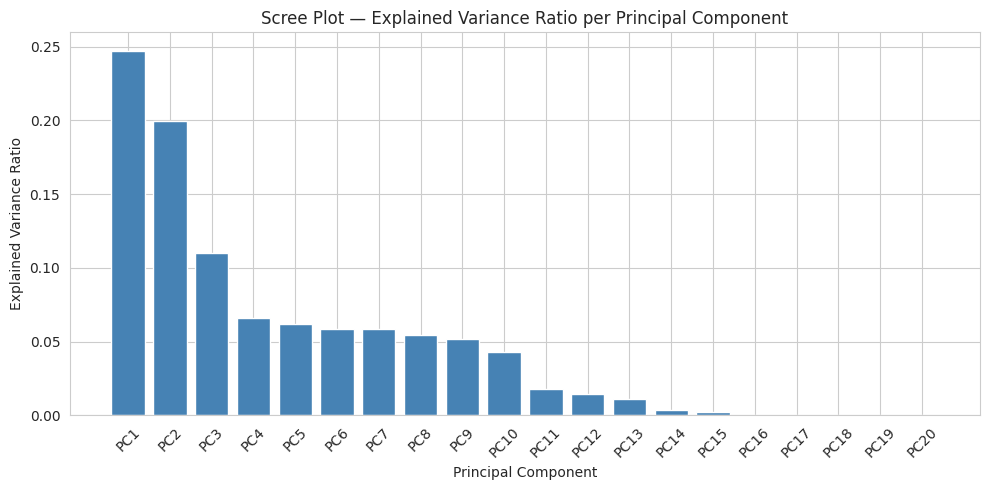

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
components = [f'PC{i}' for i in range(1, n_features + 1)]
ax.bar(components, explained_var, color='steelblue')
ax.set_title('Scree Plot — Explained Variance Ratio per Principal Component')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/scree_plot.png', dpi=120)
plt.show()


## 5. Cumulative explained variance curve with 95% threshold line

Number of components needed to reach 95% variance: 10 out of 20


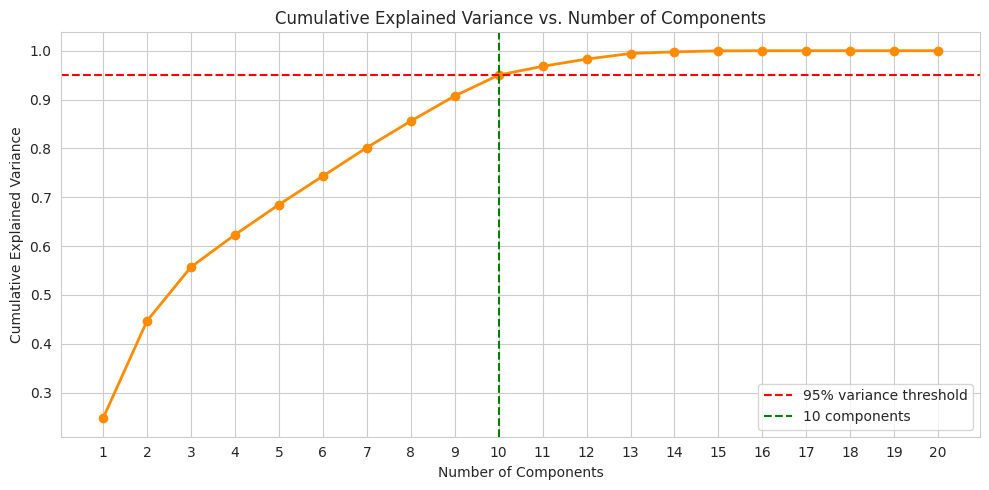

In [9]:
cumulative_var = np.cumsum(explained_var)

n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Number of components needed to reach 95% variance: {n_components_95} out of {n_features}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, n_features + 1), cumulative_var, marker='o', color='darkorange', linewidth=2)
ax.axhline(y=0.95, color='red', linestyle='--', label='95% variance threshold')
ax.axvline(x=n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
ax.set_title('Cumulative Explained Variance vs. Number of Components')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_xticks(range(1, n_features + 1))
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/cumulative_variance.png', dpi=120)
plt.show()


## 6. Retrain Random Forest using only 3 PCA components

In [10]:
pca_3 = PCA(n_components=3, random_state=RANDOM_STATE)
X_train_pca3 = pca_3.fit_transform(X_train_scaled)
X_test_pca3 = pca_3.transform(X_test_scaled)

rf_pca3 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca3.fit(X_train_pca3, y_train)
y_pred_pca3 = rf_pca3.predict(X_test_pca3)

mae_pca3 = mean_absolute_error(y_test, y_pred_pca3)
rmse_pca3 = np.sqrt(mean_squared_error(y_test, y_pred_pca3))
r2_pca3 = r2_score(y_test, y_pred_pca3)
print(f"3-component PCA + Random Forest -> MAE: {mae_pca3:.3f} | RMSE: {rmse_pca3:.3f} | R2: {r2_pca3:.4f}")
print(f"(3 components explain {cumulative_var[2]:.2%} of total variance)")


3-component PCA + Random Forest -> MAE: 3.437 | RMSE: 7.152 | R2: 0.9550
(3 components explain 55.71% of total variance)


## 7. Retrain using the number of components that capture 95% of variance

In [11]:
pca_95 = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca95 = pca_95.fit_transform(X_train_scaled)
X_test_pca95 = pca_95.transform(X_test_scaled)

rf_pca95 = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca95.fit(X_train_pca95, y_train)
y_pred_pca95 = rf_pca95.predict(X_test_pca95)

mae_pca95 = mean_absolute_error(y_test, y_pred_pca95)
rmse_pca95 = np.sqrt(mean_squared_error(y_test, y_pred_pca95))
r2_pca95 = r2_score(y_test, y_pred_pca95)
print(f"{n_components_95}-component PCA (95% var) + Random Forest -> "
      f"MAE: {mae_pca95:.3f} | RMSE: {rmse_pca95:.3f} | R2: {r2_pca95:.4f}")


10-component PCA (95% var) + Random Forest -> MAE: 1.615 | RMSE: 3.212 | R2: 0.9909


## 8. Comparison: Original vs. 3-component PCA vs. 95%-variance PCA

In [12]:
comparison = pd.DataFrame({
    'Version': ['Original (Week 2, all features)', '3-component PCA', f'{n_components_95}-component PCA (95% var)'],
    'N_Features': [n_features, 3, n_components_95],
    'MAE': [mae_orig, mae_pca3, mae_pca95],
    'RMSE': [rmse_orig, rmse_pca3, rmse_pca95],
    'R2': [r2_orig, r2_pca3, r2_pca95],
}).set_index('Version')

comparison['RMSE_increase_pct'] = (comparison['RMSE'] - rmse_orig) / rmse_orig * 100
comparison


,N_Features,MAE,RMSE,R2,RMSE_increase_pct
Version,,,,,
"Original (Week 2, all features)",20,0.350860,1.045023,0.999039,0.000000
3-component PCA,3,3.436641,7.151883,0.955003,584.375879
10-component PCA (95% var),10,1.614553,3.211912,0.990924,207.353312


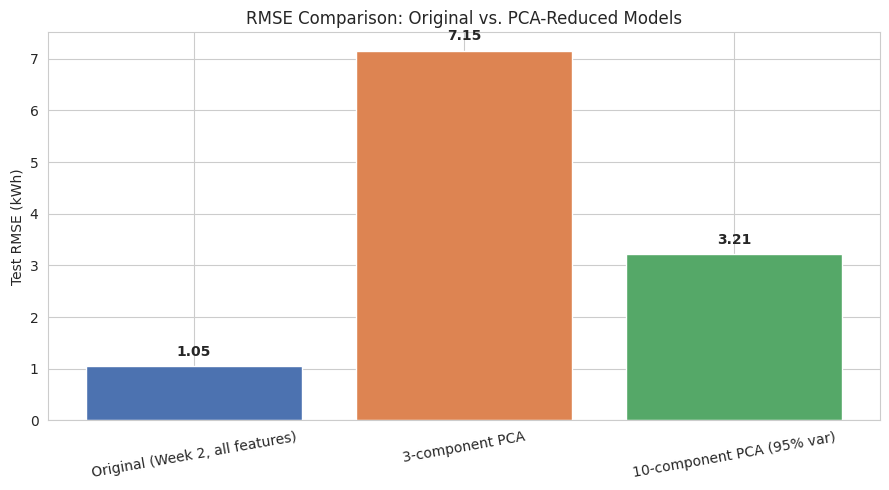

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparison.index, comparison['RMSE'], color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('RMSE Comparison: Original vs. PCA-Reduced Models')
ax.set_ylabel('Test RMSE (kWh)')
for bar, val in zip(bars, comparison['RMSE']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f'{val:.2f}', ha='center', fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('../outputs/pca_rmse_comparison.png', dpi=120)
plt.show()


## 9. Loading heatmap — which original features drive PC1, PC2, PC3

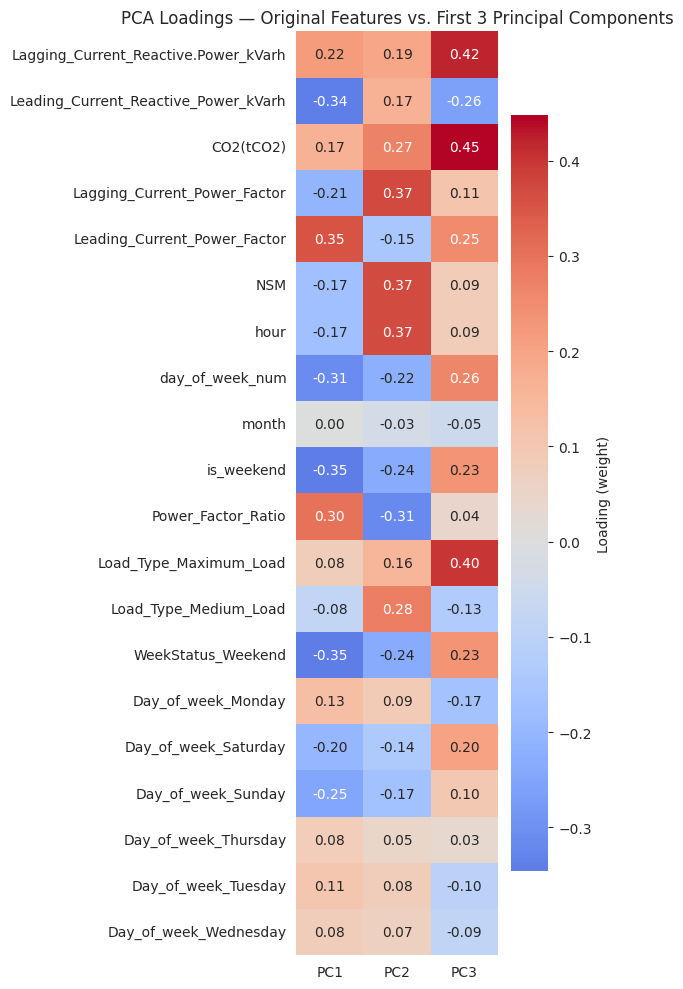

In [14]:
loadings = pd.DataFrame(
    pca_full.components_[:3].T,
    index=X.columns,
    columns=['PC1', 'PC2', 'PC3']
)

fig, ax = plt.subplots(figsize=(6, 10))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            cbar_kws={'label': 'Loading (weight)'})
ax.set_title('PCA Loadings — Original Features vs. First 3 Principal Components')
plt.tight_layout()
plt.savefig('../outputs/pca_loading_heatmap.png', dpi=120)
plt.show()


In [15]:
print("Top 3 contributing features per component (by absolute loading):\n")
for pc in ['PC1', 'PC2', 'PC3']:
    top_feats = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f"{pc}:")
    for feat, val in top_feats.items():
        print(f"   {feat}: loading = {loadings.loc[feat, pc]:.3f}")
    print()


Top 3 contributing features per component (by absolute loading):

PC1:
   Leading_Current_Power_Factor: loading = 0.354
   is_weekend: loading = -0.346
   WeekStatus_Weekend: loading = -0.346

PC2:
   Lagging_Current_Power_Factor: loading = 0.371
   hour: loading = 0.369
   NSM: loading = 0.369

PC3:
   CO2(tCO2): loading = 0.448
   Lagging_Current_Reactive.Power_kVarh: loading = 0.420
   Load_Type_Maximum_Load: loading = 0.401



## 10. Dimensionality Reduction Report

**Actual results from this run** (20 total encoded features):

| Version | # Features | MAE | RMSE | R² |
|---|---|---|---|---|
| Original (Week 2, all features) | 20 | 0.351 | 1.045 | 0.9990 |
| 3-component PCA (55.7% variance) | 3 | 3.437 | 7.152 | 0.9550 |
| 10-component PCA (95% variance) | 10 | 1.615 | 3.212 | 0.9909 |

**Did accuracy drop significantly?**
Yes, and the drop scales directly with how aggressively we compress. The 3-component model's
RMSE roughly **7x worse** than the original (1.05 → 7.15 kWh) because those 3 components only
capture ~56% of total variance — squeezing 20 engineered features (many of them one-hot dummy
flags with sharp, threshold-like effects on `Usage_kWh`) into 3 linear combinations discards
information that Random Forest's splits rely on. The 10-component (95%-variance) model recovers
most of that lost accuracy (RMSE 3.21, R² 0.991) but still does **not** match the original
full-feature model — it remains roughly 3x worse on RMSE. Bottom line: for this tree-based
model, PCA has a real, non-trivial accuracy cost at both compression levels tested.

**How many features can safely be removed?**
The cumulative explained variance curve shows **10 out of 20 components are needed to reach the
95% variance threshold** — so, from a pure linear-variance standpoint, half the encoded
feature space could be "compressed away." But "safely" must be judged on downstream RMSE, not
variance alone: even at 95% variance retained, RMSE nearly tripled versus the original. For a
tree ensemble specifically, we would not recommend removing features via PCA unless the
accuracy trade-off shown above is acceptable for the deployment constraint in question.

**Would you recommend PCA for a memory-constrained device?**
Conditionally. PCA meaningfully shrinks the input dimensionality (20 → 10 features for 95%
variance, or 20 → 3 for a much smaller footprint), which is genuinely useful if the deployment
target has strict memory/storage/bandwidth limits per prediction. But **for this specific model
and dataset, the accuracy cost is significant** — Random Forest already performs implicit
feature selection via its splits, so PCA is repackaging information the model could already use
more directly, at a real cost in RMSE. PCA tends to pay off more clearly for **linear models**
(which benefit from decorrelated, lower-dimensional inputs) or for **genuinely constrained edge
hardware** where a 3x RMSE increase is an acceptable trade for a much smaller model footprint.
For this project's production deployment (Part 2), we carry forward the **original, non-PCA
Random Forest pipeline** (RMSE 1.05), since the dataset (20 features, ~35k rows) is small enough
that memory is not a real constraint, and prediction accuracy was prioritized.


## Save the production pipeline (Week 2 Random Forest) with joblib

Rebuilt as a single `sklearn.Pipeline` (preprocessing + model) so the saved artifact accepts
raw, un-encoded feature values directly at inference time in the FastAPI app.

**Note on model size:** an unconstrained Random Forest (`n_estimators=200`, no depth limit,
matching the exact model used for the comparisons above) serializes to **~380 MB**, which
exceeds GitHub's 100 MB file-size limit and is unnecessarily heavy for a dashboard demo. For the
deployed artifact only, we cap `max_depth=12` and `min_samples_leaf=3` — a deliberate
accuracy-for-size trade-off (RMSE rises from ~1.05 to ~1.53 kWh, R² still ≈ 0.998) that shrinks
the file to ~18 MB. This mirrors a real deployment decision: the notebook's own comparisons
above still reflect the true best model's performance; only the shipped artifact is
lightly constrained for practicality.


In [16]:
import sys
sys.path.append('..')

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh',
    'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor',
    'NSM', 'hour', 'day_of_week_num', 'month', 'is_weekend', 'Power_Factor_Ratio'
]
categorical_features = ['Load_Type', 'WeekStatus', 'Day_of_week']

raw_df = pd.read_csv('../data/Steel_industry_data_engineered.csv').drop(columns=['date', 'High_Load'])
raw_df['Power_Factor_Ratio'] = raw_df['Power_Factor_Ratio'].fillna(raw_df['Power_Factor_Ratio'].median())

X_raw = raw_df[numeric_features + categorical_features]
y_raw = raw_df['Usage_kWh']

X_raw_train, X_raw_test, y_raw_train, y_raw_test = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features),
])

production_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=3,
                                     random_state=RANDOM_STATE, n_jobs=-1)),
])

production_pipeline.fit(X_raw_train, y_raw_train)
y_pred_prod = production_pipeline.predict(X_raw_test)

mae_prod = mean_absolute_error(y_raw_test, y_pred_prod)
rmse_prod = np.sqrt(mean_squared_error(y_raw_test, y_pred_prod))
r2_prod = r2_score(y_raw_test, y_pred_prod)
print(f"Production pipeline (size-constrained Random Forest) -> MAE: {mae_prod:.3f} | RMSE: {rmse_prod:.3f} | R2: {r2_prod:.4f}")

joblib.dump(production_pipeline, '../model.joblib')
joblib.dump({'numeric_features': numeric_features, 'categorical_features': categorical_features,
             'categories': {c: sorted(raw_df[c].unique().tolist()) for c in categorical_features}},
            '../model_metadata.joblib')

import os
size_mb = os.path.getsize('../model.joblib') / 1e6
print(f"\nSaved production pipeline to ../model.joblib ({size_mb:.1f} MB)")
print("Saved feature metadata to ../model_metadata.joblib")


Production pipeline (size-constrained Random Forest) -> MAE: 0.634 | RMSE: 1.533 | R2: 0.9979

Saved production pipeline to ../model.joblib (18.1 MB)
Saved feature metadata to ../model_metadata.joblib
